In [1]:
import torch
from torchvision import transforms

from sklearn.metrics import f1_score, confusion_matrix, classification_report
import seaborn as sns


PARTE 2: PREPARACIÓN DATASET

In [2]:
# transformaciones para entrenamiento

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# transformaciones para validación y test
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

PARTE 3: CARGAR EL DATASET

In [8]:
import os

# En Kaggle, los datasets se encuentran en /kaggle/input/<nombre-dataset>
# Ajusta el nombre del dataset según el que hayas subido en Kaggle
ruta = '/kaggle/input/datasets/amelianadiamaziuk/dataset-fusionado/dataset_fusionado'

# Verificar que el directorio existe
if not os.path.exists(ruta):
    print(f"Error: El directorio '{ruta}' no existe.")
    print("Asegúrate de haber añadido tu dataset en Kaggle y de que la ruta es correcta.")
    files = []
else:
    files = os.listdir(ruta)
    print(f"Total imágenes: {len(files)}'")
    print('Primeros 10: ')
    for f in files[:10]:
        print(f)


Total imágenes: 3'
Primeros 10: 
val
test
train


In [9]:
from torchvision import datasets
from torch.utils.data import DataLoader


class ImageFolder(datasets.ImageFolder):
  def __getitem__(self, index):
    try:
      return super(ImageFolder, self).__getitem__(index)
    except:
      return self.__getitem__(index + 1)

# Load pre-split datasets from subfolders
train_dataset = ImageFolder(f"{ruta}/train", transform=transform_train)
val_dataset = ImageFolder(f"{ruta}/val", transform=transform_val)
test_dataset = ImageFolder(f"{ruta}/test", transform=transform_val)

print(f"Total imágenes en train: {len(train_dataset)}")
print(f"Total imágenes en val: {len(val_dataset)}")
print(f"Total imágenes en test: {len(test_dataset)}")

classes = train_dataset.classes # Define 'classes' variable from one of the datasets
print(f"Clases: {classes}")



Total imágenes en train: 4745
Total imágenes en val: 1013
Total imágenes en test: 1027
Clases: ['cups', 'forks', 'glasses', 'knives', 'plates', 'spoons']


PARTE 4: CARGAR DATOS

In [10]:
train_loader = DataLoader(train_dataset, batch_size = 16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle=False)

print(f"Batches en train: {len(train_loader)}")
print(f"Batches en val: {len(val_loader)}")
print(f"Batches en test: {len(test_loader)}")


Batches en train: 297
Batches en val: 64
Batches en test: 65


PARTE 5: ARQUITECTURA CNN

In [11]:
import torch.nn as nn

class BaselineCNN(nn.Module):
  def __init__(self, num_classes=6, dropout_rate=0.5):
    super(BaselineCNN, self).__init__()


    # extracción características

    # bloque 1 : 3 canales RGB --> 32 filtros

    self.bloque1 = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        #nn.Dropout(dropout_rate)
    )

    # bloque 2 : 32 filtros --> 64

    self.bloque2 = nn.Sequential(
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        #nn.Dropout(dropout_rate)
    )

    # bloque 3 : 64 filtros -> 128 filtros

    self.bloque3 = nn.Sequential(
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        #nn.Dropout(dropout_rate)
    )


    # clasificación

    self.clasificador = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128 * 28 * 28, 256),
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        nn.Linear(256, num_classes)
    )

  def forward(self, x):
    x = self.bloque1(x)
    x = self.bloque2(x)
    x = self.bloque3(x)
    x = self.clasificador(x)
    return x

In [12]:
modelo = BaselineCNN(num_classes=6, dropout_rate=0.5)
print(modelo)

BaselineCNN(
  (bloque1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloque2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloque3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (clasificador): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352,

In [13]:
# vamos a probar que la red funciona con el tamaño de la imágenes

imagen_prueba = torch.randn(1, 3, 224, 224)
with torch.no_grad():
  salida = modelo(imagen_prueba)

print(imagen_prueba.shape)
print(salida.shape)
print(classes)

torch.Size([1, 3, 224, 224])
torch.Size([1, 6])
['cups', 'forks', 'glasses', 'knives', 'plates', 'spoons']


In [15]:
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.02, **kwargs):
        defaults = dict(rho=rho, **kwargs)
        super(SAM, self).__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups[0]['params'], **kwargs)
        self.rho = rho  # ← guardamos rho directamente

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = self.rho / (grad_norm + 1e-12)  # ← usamos self.rho
            for p in group['params']:
                if p.grad is None: continue
                e_w = p.grad * scale.to(p)
                p.add_(e_w)
                self.state[p]['e_w'] = e_w
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                p.sub_(self.state[p]['e_w'])
        self.base_optimizer.step()
        if zero_grad: self.zero_grad()

    def _grad_norm(self):
        shared_device = self.param_groups[0]['params'][0].device
        return torch.norm(torch.stack([
            p.grad.norm(p=2).to(shared_device)
            for group in self.param_groups
            for p in group['params']
            if p.grad is not None
        ]), p=2)

print("✅ SAM listo")

✅ SAM listo


PARTE 6: ENTRENAMIENTO

In [24]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


modelo = BaselineCNN(num_classes=6, dropout_rate=0.5).to(device)
optimizer = SAM(modelo.parameters(), torch.optim.SGD, lr=0.0001, momentum = 0.9)

criterio = nn.CrossEntropyLoss()
epochs = 20

hist_loss_train = []
hist_acc_train = [] # Nueva lista para la precisión de entrenamiento
hist_loss_val = []  # Nueva lista para la pérdida de validación
hist_acc_val = []

for epoch in range(epochs):

  # ENTRNAMIENTO

  modelo.train()
  loss_total_train = 0
  correctas_train = 0 # Para precisión de entrenamiento
  total_train = 0     # Para precisión de entrenamiento

  for imagenes, etiquetas in train_loader:
    imagenes = imagenes.to(device)
    etiquetas = etiquetas.to(device)

    salida = modelo(imagenes)
    loss = criterio(salida, etiquetas) # calcula error
    loss.backward() # backward pass
    optimizer.first_step(zero_grad=True) # actualiza pesos

    salida2 = modelo(imagenes) # forward pass
    loss2 = criterio(salida2, etiquetas) # calcula error
    loss2.backward() # backward pass
    optimizer.second_step(zero_grad=True) # actualiza pesos


    loss_total_train += loss.item()

    # Calcular precisión en entrenamiento
    _, predicciones_train = torch.max(salida, 1)
    correctas_train += (predicciones_train == etiquetas).sum().item()
    total_train += etiquetas.size(0)

  loss_medio_train = loss_total_train / len(train_loader)
  acc_train = correctas_train / total_train


  # fase de validación

  modelo.eval()
  correctas_val = 0
  total_val = 0
  loss_total_val = 0 # Para pérdida de validación

  with torch.no_grad():
    for imagenes, etiquetas in val_loader:
      imagenes = imagenes.to(device)
      etiquetas = etiquetas.to(device)
      salida = modelo(imagenes)
      loss_val = criterio(salida, etiquetas) # Calcula la pérdida de validación
      loss_total_val += loss_val.item()

      _, predicciones_val = torch.max(salida, 1)
      correctas_val += (predicciones_val == etiquetas).sum().item()
      total_val += etiquetas.size(0)

  loss_medio_val = loss_total_val / len(val_loader)
  acc_val = correctas_val / total_val

  hist_loss_train.append(loss_medio_train)
  hist_acc_train.append(acc_train) # Añadir precisión de entrenamiento
  hist_loss_val.append(loss_medio_val) # Añadir pérdida de validación
  hist_acc_val.append(acc_val)

  print(f"Epoch: {epoch+1}/{epochs}")
  print(f"Loss train: {loss_medio_train:.4f} | Acc train: {acc_train:.4f}")
  print(f"Loss val:   {loss_medio_val:.4f} | Acc val:   {acc_val:.4f}")

Epoch: 1/20
Loss train: 1.6546 | Acc train: 0.3098
Loss val:   1.5532 | Acc val:   0.3741
Epoch: 2/20
Loss train: 1.4867 | Acc train: 0.3861
Loss val:   1.4290 | Acc val:   0.4344
Epoch: 3/20
Loss train: 1.3964 | Acc train: 0.4314
Loss val:   1.3502 | Acc val:   0.4452
Epoch: 4/20
Loss train: 1.3280 | Acc train: 0.4531
Loss val:   1.2783 | Acc val:   0.4926
Epoch: 5/20
Loss train: 1.2604 | Acc train: 0.4932
Loss val:   1.2370 | Acc val:   0.5114
Epoch: 6/20
Loss train: 1.2140 | Acc train: 0.5123
Loss val:   1.2109 | Acc val:   0.5212
Epoch: 7/20
Loss train: 1.1651 | Acc train: 0.5439
Loss val:   1.1768 | Acc val:   0.5222
Epoch: 8/20
Loss train: 1.1040 | Acc train: 0.5629
Loss val:   1.1407 | Acc val:   0.5726
Epoch: 9/20
Loss train: 1.0597 | Acc train: 0.5838
Loss val:   1.1167 | Acc val:   0.5696
Epoch: 10/20
Loss train: 1.0091 | Acc train: 0.6061
Loss val:   1.0727 | Acc val:   0.5864
Epoch: 11/20
Loss train: 0.9656 | Acc train: 0.6236
Loss val:   1.0439 | Acc val:   0.6041
Epoch: 1

In [25]:

# EVALUACIÓN FINAL EN TEST SET
print("\n" + "="*60)
print("EVALUACIÓN EN TEST SET")
print("="*60 + "\n")

modelo.eval()
correctas_test = 0
total_test = 0
todas_predicciones_test = []
todas_etiquetas_test = []

with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)

        salida = modelo(imagenes)
        _, predicciones = torch.max(salida, 1)

        correctas_test += (predicciones == etiquetas).sum().item()
        total_test += etiquetas.size(0)

        todas_predicciones_test.extend(predicciones.cpu().numpy())
        todas_etiquetas_test.extend(etiquetas.cpu().numpy())

# Calcular métricas finales
acc_test = correctas_test / total_test
f1_test = f1_score(todas_etiquetas_test, todas_predicciones_test, average='macro')

print(f"Test Accuracy:     {acc_test:.4f}")
print(f"Test Macro F1-Score: {f1_test:.4f}")

# Classification Report detallado
print("\n" + "="*60)
print("CLASSIFICATION REPORT (TEST SET)")
print("="*60)
print(classification_report(todas_etiquetas_test, todas_predicciones_test,
                          target_names=classes, digits=4))

print("\n✓ Evaluación en test completada")


EVALUACIÓN EN TEST SET

Test Accuracy:     0.6173
Test Macro F1-Score: 0.6136

CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

        cups     0.7278    0.6053    0.6609       190
       forks     0.5395    0.5359    0.5377       153
     glasses     0.6150    0.7572    0.6788       173
      knives     0.5942    0.4881    0.5359       168
      plates     0.7725    0.7167    0.7435       180
      spoons     0.4774    0.5828    0.5249       163

    accuracy                         0.6173      1027
   macro avg     0.6211    0.6143    0.6136      1027
weighted avg     0.6270    0.6173    0.6180      1027


✓ Evaluación en test completada


### PARTE 7: Visualización de los Resultados

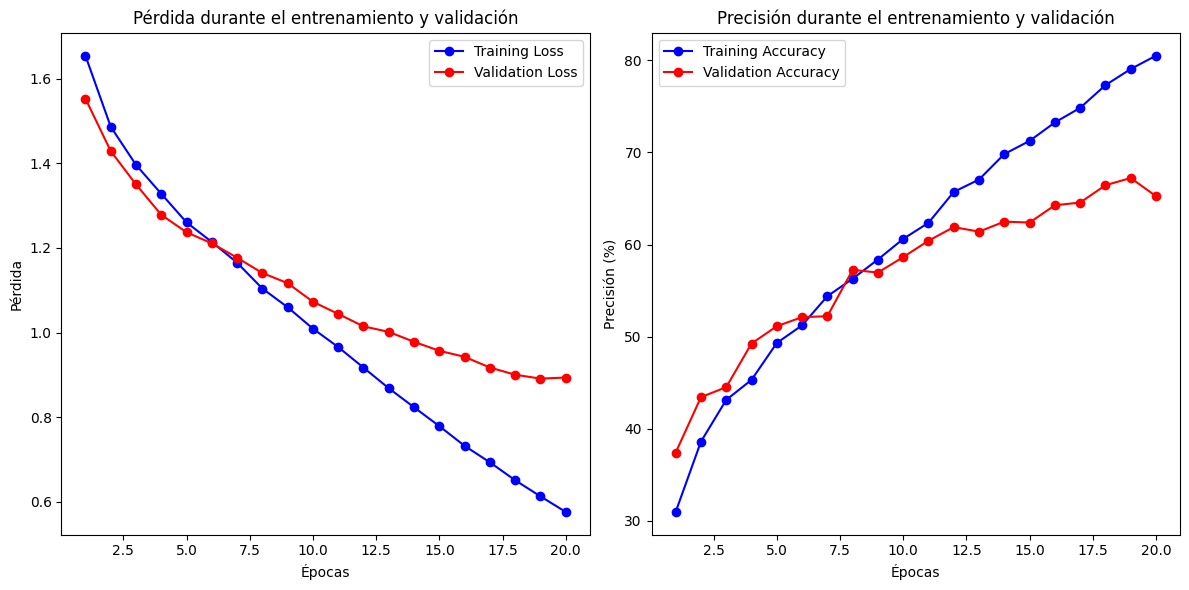

In [26]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs +1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Gráfico de Pérdida (Train y Val)
ax1.plot(epochs_range, hist_loss_train, 'b-o', label='Training Loss')
ax1.plot(epochs_range, hist_loss_val, 'r-o', label='Validation Loss')
ax1.set_title("Pérdida durante el entrenamiento y validación")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Pérdida")
ax1.legend()

# Gráfico de Precisión (Train y Val)
ax2.plot(epochs_range, [a * 100 for a in hist_acc_train], 'b-o', label='Training Accuracy')
ax2.plot(epochs_range, [a * 100 for a in hist_acc_val], 'r-o', label='Validation Accuracy')
ax2.set_title("Precisión durante el entrenamiento y validación")
ax2.set_xlabel("Épocas")
ax2.set_ylabel("Precisión (%)")
ax2.legend()

plt.tight_layout()
plt.show()

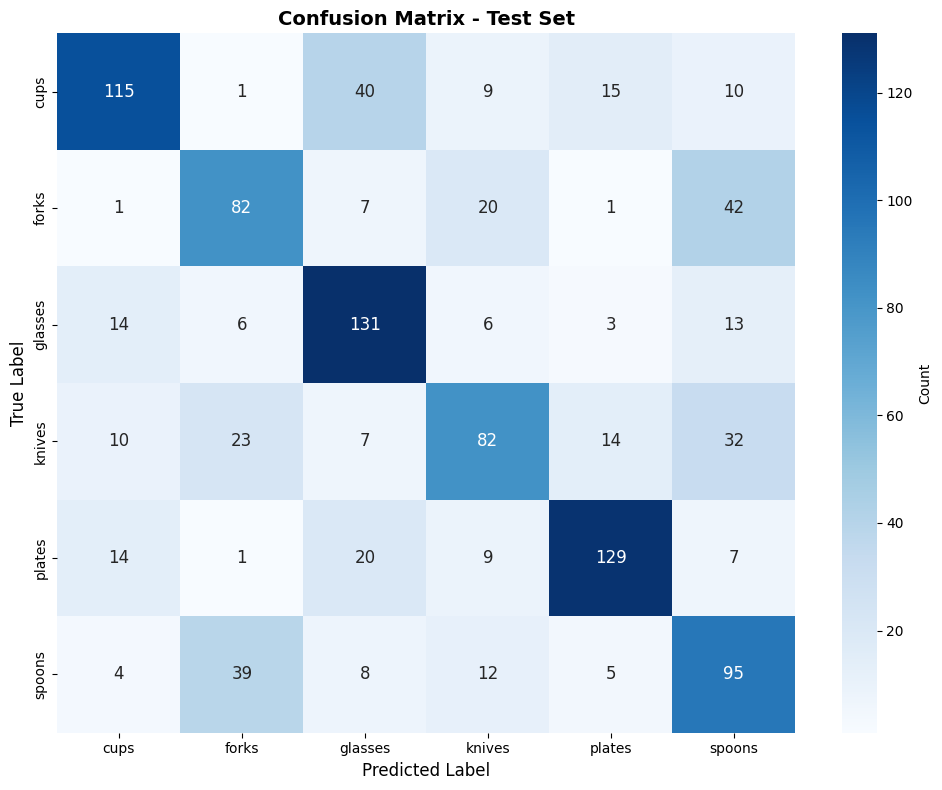

✓ Confusion Matrix guardada como 'confusion_matrix.png'

Total imágenes mal clasificadas: 393


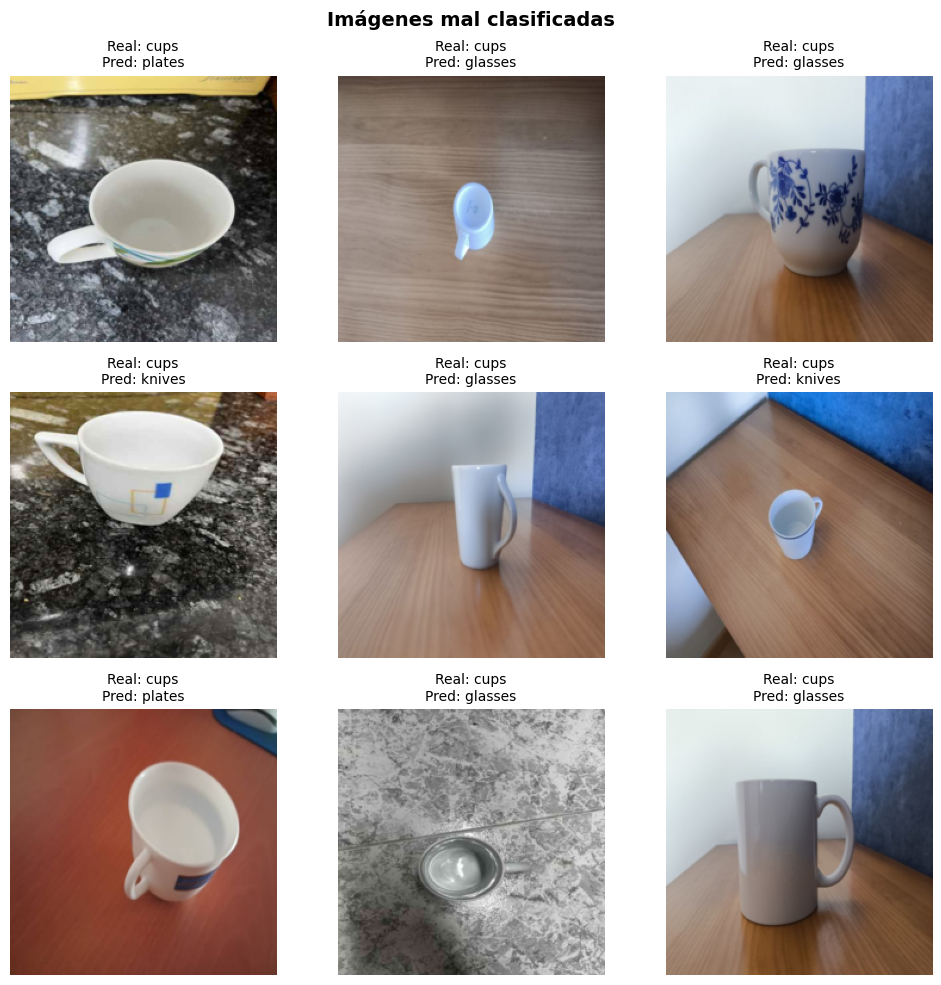

In [27]:
# ============================================================================
# FIGURA 2: CONFUSION MATRIX
# ============================================================================

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(todas_etiquetas_test, todas_predicciones_test)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 12})
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Confusion Matrix guardada como 'confusion_matrix.png'")

# ── 2. IMÁGENES MAL CLASIFICADAS ─────────────────────────────────
# Buscamos índices donde la predicción fue incorrecta
errores = [(i, p, e) for i, (p, e) in enumerate(zip(todas_predicciones_test, todas_etiquetas_test)) if p != e]
print(f"\nTotal imágenes mal clasificadas: {len(errores)}")

# Mostramos las primeras 9
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for idx, (i, pred, real) in enumerate(errores[:9]):
    imagen, _ = test_dataset[i]
    # Desnormalizamos para visualizar
    mean = torch.tensor([0.485, 0.456, 0.406])
    std  = torch.tensor([0.229, 0.224, 0.225])
    imagen = imagen * std[:, None, None] + mean[:, None, None]
    imagen = imagen.permute(1, 2, 0).numpy()
    imagen = np.clip(imagen, 0, 1)

    axes[idx].imshow(imagen)
    axes[idx].set_title(f'Real: {classes[real]}\nPred: {classes[pred]}', fontsize=10)
    axes[idx].axis('off')

# Ocultamos los ejes sobrantes si hay menos de 9 errores
for idx in range(len(errores[:9]), 9):
    axes[idx].axis('off')

plt.suptitle('Imágenes mal clasificadas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('misclassified.png', dpi=150)
plt.show()

In [29]:
# ============================================================================
# RESUMEN FINAL DE EXPERIMENTO 1
# ============================================================================

print("\n" + "="*70)
print("RESUMEN FINAL - EXPERIMENTO 2 BASE")
print("="*70)

print(f"\n{'MÉTRICA':<30} {'VALIDACIÓN':<15} {'TEST':<15}")
print("-" * 60)
print(f"{'Accuracy':<30} {hist_acc_val[-1]:<15.4f} {acc_test:<15.4f}")
print(f"{'Macro F1-Score':<30}{"":<17}{f1_test:<15.4f}")
print(f"{'Training Loss (final)':<30} {hist_loss_train[-1]:<15.4f}")

print("\n" + "="*70)
print("ARCHIVOS GENERADOS")
print("="*70)
print("✓ training_curves.png")
print("✓ confusion_matrix.png")
print("✓ misclassified.png")
print("\n✓ Experimento 2 base COMPLETADO")


RESUMEN FINAL - EXPERIMENTO 2 BASE

MÉTRICA                        VALIDACIÓN      TEST           
------------------------------------------------------------
Accuracy                       0.6525          0.6173         
Macro F1-Score                                 0.6136         
Training Loss (final)          0.5759         

ARCHIVOS GENERADOS
✓ training_curves.png
✓ confusion_matrix.png
✓ misclassified.png

✓ Experimento 2 base COMPLETADO
